# 多项式拟合

### 1.导入库

In [7]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l
from utils import train_epoch_ch3

### 2.用三阶多项式生成数据集

$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.1^2).$

In [8]:
# 多项式的最大阶数，意味着模型最多有，x^0，x^1，... ，x^19共20个特征。
max_degree = 20 
# 训练和测试数据集大小
n_train, n_test = 100, 100  
# 真实权重，只给前四个赋值，所以真实函数只有三阶
true_w = np.zeros(max_degree) 
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])
# 生成输入数据
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
# 创建特征
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    # gamma(n)=(n-1)!
    # 因为高阶项数值可能非常大，除以阶乘可以减少数值范围，使训练稳定
    poly_features[:, i] /= math.gamma(i + 1) 
# 生成标签
labels = np.dot(poly_features, true_w)
# 加入噪声
labels += np.random.normal(scale=0.1, size=labels.shape)
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]
features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.8368],
         [-0.9817]]),
 tensor([[ 1.0000e+00, -8.3684e-01,  3.5015e-01, -9.7672e-02,  2.0434e-02,
          -3.4200e-03,  4.7699e-04, -5.7023e-05,  5.9649e-06, -5.5463e-07,
           4.6413e-08, -3.5309e-09,  2.4623e-10, -1.5851e-11,  9.4745e-13,
          -5.2857e-14,  2.7646e-15, -1.3609e-16,  6.3268e-18, -2.7866e-19],
         [ 1.0000e+00, -9.8166e-01,  4.8183e-01, -1.5766e-01,  3.8693e-02,
          -7.5966e-03,  1.2429e-03, -1.7430e-04,  2.1388e-05, -2.3328e-06,
           2.2900e-07, -2.0437e-08,  1.6718e-09, -1.2624e-10,  8.8520e-12,
          -5.7931e-13,  3.5543e-14, -2.0524e-15,  1.1193e-16, -5.7831e-18]]),
 tensor([2.3514, 1.4205]))

### 3.评估损失

In [9]:
def evaluate_loss(net, data_iter, loss):  
    # 损失的总和，样本数量
    metric = d2l.Accumulator(2)  
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

### 4.训练函数

In [10]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

### 5.正常拟合

weight: [[ 4.982135   1.1921804 -3.4035313  5.600958 ]]


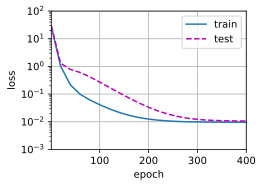

In [11]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

### 6.欠拟合

weight: [[3.2058127 4.778053 ]]


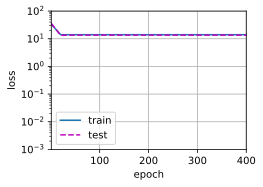

In [12]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

### 7.过拟合

weight: [[ 4.977829    1.2515688  -3.40888     5.2837777   0.08567856  0.9276205
   0.02930515 -0.08682322 -0.09955871 -0.22535348 -0.06798319  0.12671879
   0.2224757  -0.03365909  0.0793607   0.00739929 -0.13464971  0.17914563
   0.04394767  0.08315191]]


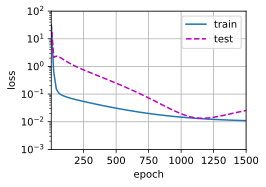

In [13]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)